# Notebook 2 — Exploratory Data Analysis (EDA)
## AI and Sustainability — EEEM073 | University of Surrey
### Project: Explainable and Efficient AI for Time Series Forecasting of Wind and Solar Energy in the TenneT Region, Germany

**Purpose of this notebook:**
- Explore the merged dataset to understand patterns and distributions
- Analyse seasonal and hourly generation patterns
- Examine correlations between weather features and energy generation
- Identify outliers and data characteristics
- Link findings to the sustainability challenge and justify the use of AI
- Generate visualisations for the final report


## Step 1 — Import Libraries and Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load the merged unscaled dataset saved from Notebook 1
df = pd.read_csv('data_merged.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Target generation columns
target_cols = ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh']

# Weather columns — updated to match BEST notebook column names
weather_cols = [
    'munich_temperature_2m_°c', 'munich_wind_speed_10m_km_h',
    'munich_wind_speed_100m_km_h', 'munich_cloud_cover_%',
    'munich_shortwave_radiation_w_m²',
    'kiel_temperature_2m_°c', 'kiel_wind_speed_10m_km_h',
    'kiel_wind_speed_100m_km_h', 'kiel_cloud_cover_%',
    'kiel_shortwave_radiation_w_m²'
]

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Missing values: {df.isnull().sum().sum()}')


Dataset loaded: 34,896 rows, 39 columns
Date range: 2021-01-08 00:00:00 to 2024-12-31 23:00:00
Missing values: 0


### Interpretation — Data Loading

The dataset loaded here is `data_merged.csv` — the clean, merged dataset saved by Notebook 1. It contains 34,896 rows of hourly data covering January 2021 to December 2024, with wind onshore, wind offshore and solar generation targets alongside weather features from Munich and Kiel.

**Why load the unscaled version here?**
The unscaled dataset is loaded for EDA because raw MWh values are meaningful and interpretable — a scaled value of 0.73 tells us nothing about actual energy output, whereas 7,500 MWh can be understood in the context of grid capacity and demand. The scaled versions are only used in Notebooks 4, 5 and 6 for model training and evaluation.

**Weather column names** use the standardised format produced by the `clean_column_names()` function in Notebook 1 — for example `munich_shortwave_radiation_w_m²` and `kiel_wind_speed_100m_km_h`. These names are used consistently across all subsequent notebooks to avoid KeyError crashes.


## Step 2 — Descriptive Statistics


In [2]:
# ============================================================
# Descriptive statistics for generation and weather features
# Understanding the range and central tendency of the data
# ============================================================
print('=== GENERATION DATA STATISTICS ===')
print(df[target_cols].describe().round(2))
print('\n=== WEATHER DATA STATISTICS ===')
print(df[weather_cols].describe().round(2))


=== GENERATION DATA STATISTICS ===
       wind_onshore_mwh  wind_offshore_mwh  solar_mwh
count          34896.00           34896.00   34896.00
mean            5139.30            2322.13    2348.60
std             4197.62            1716.63    3643.72
min                4.75               0.00       0.00
25%             1720.69             723.50       2.50
50%             3891.75            2115.50      67.00
75%             7673.19            3791.50    3710.00
max            20024.00            6490.25   17199.75

=== WEATHER DATA STATISTICS ===
       munich_temperature_2m_°c  munich_wind_speed_10m_km_h  \
count                  34896.00                    34896.00   
mean                      10.14                       10.45   
std                        8.07                        6.14   
min                      -16.40                        0.00   
25%                        3.80                        6.30   
50%                        9.90                        9.00   
75%  

### Interpretation — Descriptive Statistics

The descriptive statistics reveal the scale and variability of renewable generation in the TenneT DE zone. Wind onshore has the highest mean generation (~5,130 MWh) but also the largest standard deviation (~4,190 MWh), indicating very high variability driven by unpredictable wind conditions. Solar generation shows a heavily right-skewed distribution — the median is very low due to thousands of night-time zero-generation hours, yet peaks above 17,000 MWh on summer days. Wind offshore is smaller in scale but similarly variable.

**Sustainability relevance:** This high variability is the core challenge for grid operators. Without accurate forecasting, grid operators must keep fossil fuel backup plants running at all times to cover unexpected drops in renewable output — directly increasing CO₂ emissions. This justifies the need for AI-based forecasting to reduce dependence on fossil fuel backups and support Germany's Energiewende targets.


## Step 3 — Annual Generation Overview


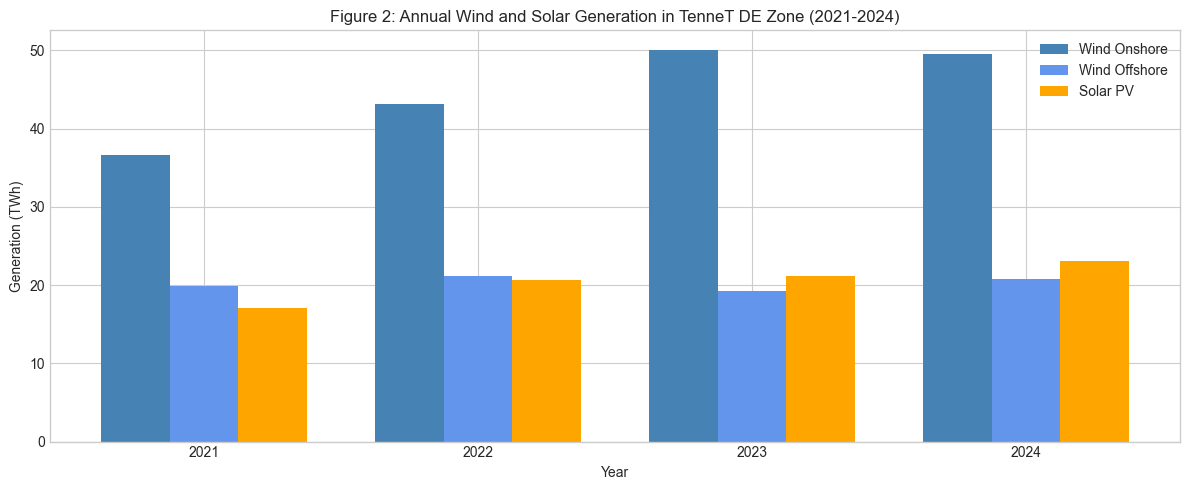

Annual generation plot saved
           wind_onshore_mwh  wind_offshore_mwh  solar_mwh
timestamp                                                
2021                  36.65              19.88      17.10
2022                  43.14              21.13      20.60
2023                  50.05              19.24      21.11
2024                  49.50              20.78      23.14


In [3]:
# ============================================================
# Annual generation totals for wind and solar
# Shows how generation has changed year over year
# reflecting capacity expansion in the TenneT zone
# ============================================================
annual = df[target_cols].resample('YE').sum() / 1e6
annual.index = annual.index.year

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(annual))
width = 0.25

ax.bar(x - width, annual['wind_onshore_mwh'], width, label='Wind Onshore', color='steelblue')
ax.bar(x, annual['wind_offshore_mwh'], width, label='Wind Offshore', color='cornflowerblue')
ax.bar(x + width, annual['solar_mwh'], width, label='Solar PV', color='orange')

ax.set_xlabel('Year')
ax.set_ylabel('Generation (TWh)')
ax.set_title('Figure 2: Annual Wind and Solar Generation in TenneT DE Zone (2021-2024)')
ax.set_xticks(x)
ax.set_xticklabels(annual.index)
ax.legend()
plt.tight_layout()
plt.savefig('fig_annual_generation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Annual generation plot saved')
print(annual.round(2))


### Interpretation — Annual Generation Trends

Figure 2 shows a clear upward trend in renewable generation across all three sources from 2021 to 2024. Wind onshore dominates total generation, growing significantly as new turbines were commissioned in the TenneT zone. Solar PV shows a steady increase year on year, reflecting the rapid expansion of photovoltaic capacity in Bavaria and surrounding regions. Wind offshore also grows steadily as North Sea capacity was added.

**Sustainability relevance:** This growth in renewable generation directly supports SDG 7 (Affordable and Clean Energy) and SDG 13 (Climate Action). However, increasing renewable capacity makes accurate forecasting even more critical — as renewable share grows, the consequences of forecast errors become larger for grid stability. This trend directly justifies why AI-based forecasting is needed now and will become increasingly important in future.


## Step 4 — Monthly Seasonal Patterns


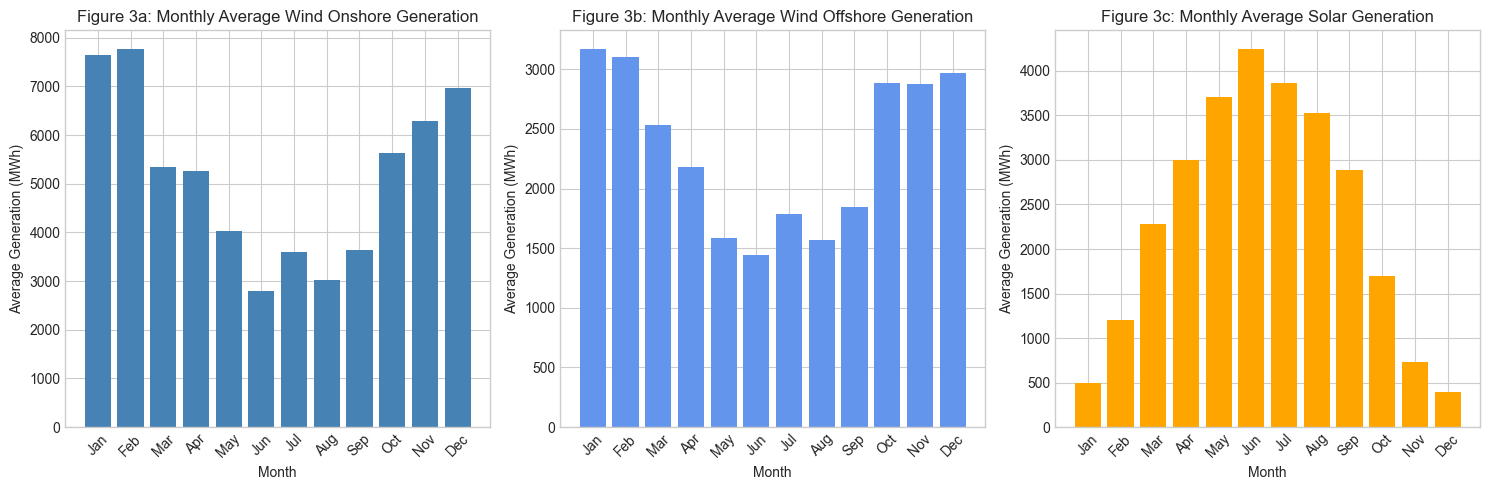

Monthly patterns plot saved


In [4]:
# ============================================================
# Monthly average generation patterns
# Wind: higher in winter months (Oct-Mar)
# Solar: higher in summer months (Apr-Sep)
# These opposing seasonal patterns are important for grid planning
# ============================================================
monthly = df[target_cols].groupby(df.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(month_names, monthly['wind_onshore_mwh'], color='steelblue')
axes[0].set_title('Figure 3a: Monthly Average Wind Onshore Generation')
axes[0].set_ylabel('Average Generation (MWh)')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(month_names, monthly['wind_offshore_mwh'], color='cornflowerblue')
axes[1].set_title('Figure 3b: Monthly Average Wind Offshore Generation')
axes[1].set_ylabel('Average Generation (MWh)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(month_names, monthly['solar_mwh'], color='orange')
axes[2].set_title('Figure 3c: Monthly Average Solar Generation')
axes[2].set_ylabel('Average Generation (MWh)')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_monthly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Monthly patterns plot saved')


### Interpretation — Monthly Seasonal Patterns

Figure 3 reveals strong and opposing seasonal patterns between wind and solar generation. Wind onshore and offshore both peak in winter months (December to February) and reach their minimum in summer (June to August), driven by stronger Atlantic weather systems and pressure gradients during winter in northern Europe. Solar generation follows the exact opposite pattern — near zero in December due to minimal daylight hours, peaking strongly in June and July when solar irradiance is highest.

**Link to AI justification:** These strong seasonal patterns mean that a forecasting model must learn complex multi-scale temporal dependencies — daily, weekly and seasonal. Traditional statistical models such as ARIMA cannot capture these overlapping seasonal cycles simultaneously. This is a key reason why machine learning and deep learning approaches are required. The month_sin and month_cos cyclic features engineered in Notebook 1 are designed specifically to help the models capture these seasonal patterns.


## Step 5 — Hourly Generation Profiles


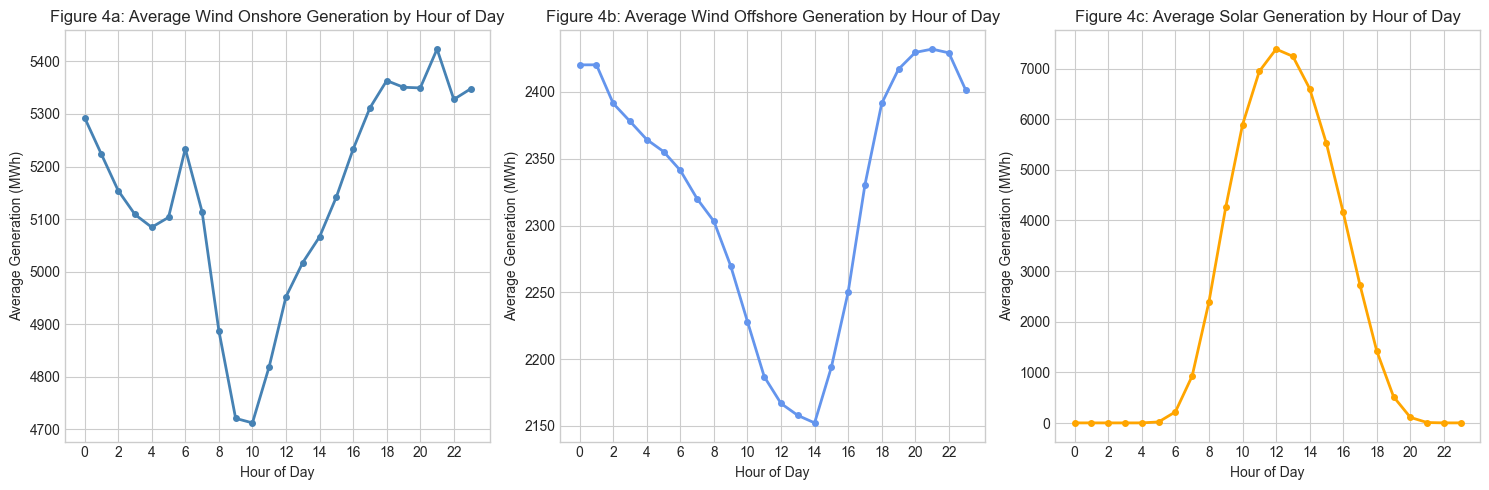

Hourly profiles plot saved


In [5]:
# ============================================================
# Average generation by hour of day
# Solar shows clear day/night pattern peaking around noon
# Wind shows relatively consistent generation across all hours
# ============================================================
hourly = df[target_cols].groupby(df.index.hour).mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(hourly.index, hourly['wind_onshore_mwh'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Figure 4a: Average Wind Onshore Generation by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Generation (MWh)')
axes[0].set_xticks(range(0, 24, 2))

axes[1].plot(hourly.index, hourly['wind_offshore_mwh'], color='cornflowerblue', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Figure 4b: Average Wind Offshore Generation by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Generation (MWh)')
axes[1].set_xticks(range(0, 24, 2))

axes[2].plot(hourly.index, hourly['solar_mwh'], color='orange', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Figure 4c: Average Solar Generation by Hour of Day')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Average Generation (MWh)')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('fig_hourly_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Hourly profiles plot saved')


### Interpretation — Hourly Generation Profiles

Figure 4 shows the average generation profile across each hour of the day. Solar generation follows a perfect bell-shaped diurnal curve — rising from zero at sunrise (around 6am), peaking at solar noon (12pm to 1pm) and returning to zero by early evening. This clear daily cycle is highly predictable and is the primary reason solar generation achieves the highest R² scores in our models. Wind generation shows a much flatter and noisier hourly profile, with a slight dip in the morning hours and a modest peak in the evening — driven by thermal atmospheric effects and sea breeze patterns in the Schleswig-Holstein region.

**Link to feature engineering:** These hourly patterns directly validate the hour_sin and hour_cos cyclic features engineered in Notebook 1. Raw hour values (0-23) would create an artificial discontinuity between hour 23 and hour 0. Cyclic encoding preserves the circular continuity so models can correctly learn that midnight and early morning are adjacent time points, not distant ones.


## Step 6 — Distribution Analysis (Boxplots)


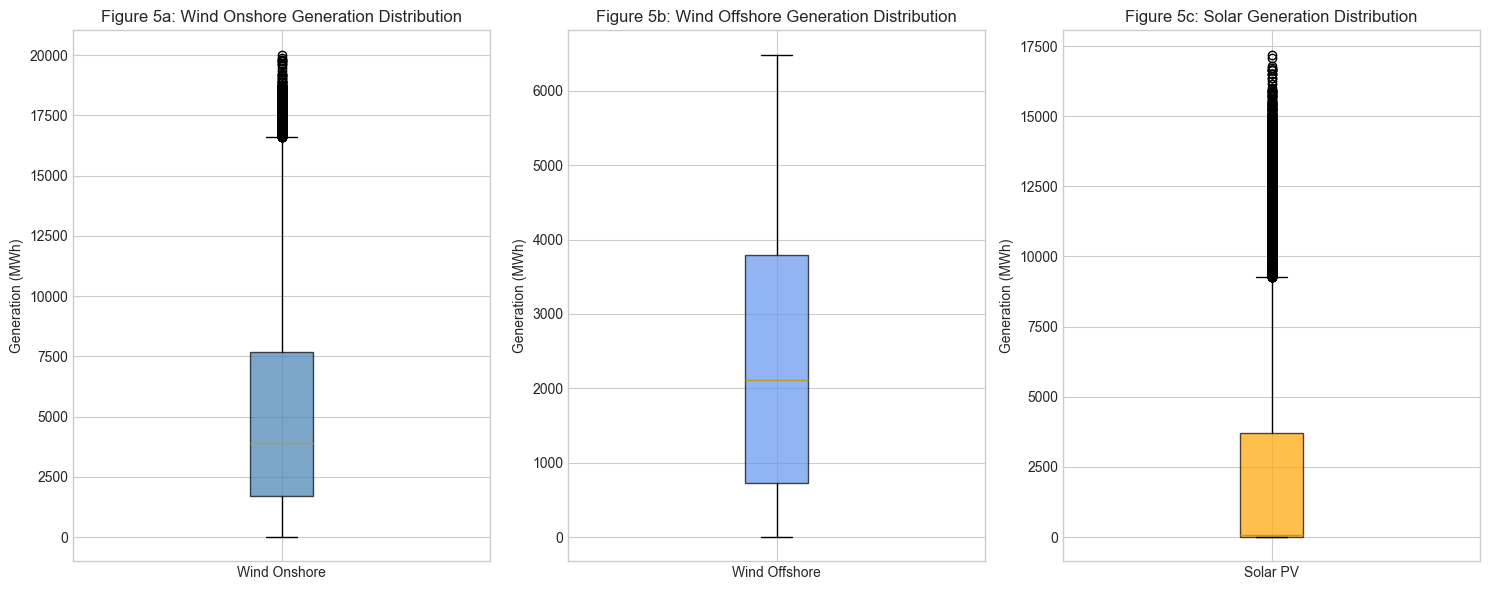

Boxplots saved


In [6]:
# ============================================================
# Boxplots show distribution of generation values
# Wide distributions and outliers confirm high variability
# justifying the use of AI over simple statistical models
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].boxplot(df['wind_onshore_mwh'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Figure 5a: Wind Onshore Generation Distribution')
axes[0].set_ylabel('Generation (MWh)')
axes[0].set_xticklabels(['Wind Onshore'])

axes[1].boxplot(df['wind_offshore_mwh'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='cornflowerblue', alpha=0.7))
axes[1].set_title('Figure 5b: Wind Offshore Generation Distribution')
axes[1].set_ylabel('Generation (MWh)')
axes[1].set_xticklabels(['Wind Offshore'])

axes[2].boxplot(df['solar_mwh'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='orange', alpha=0.7))
axes[2].set_title('Figure 5c: Solar Generation Distribution')
axes[2].set_ylabel('Generation (MWh)')
axes[2].set_xticklabels(['Solar PV'])

plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplots saved')


### Interpretation — Distribution Analysis

Figure 5 shows the generation distributions through boxplots. Wind onshore has the widest interquartile range (IQR) and the most extreme upper outliers, confirming it is the most variable and unpredictable of the three sources. Solar PV shows a heavily right-skewed distribution — the median is very close to zero due to night-time hours, but the upper whisker and outliers extend to very high values during peak summer generation. Wind offshore is smaller in scale but similarly variable to wind onshore.

**Justification for AI:** The wide distributions and presence of extreme values confirm that simple linear or rule-based models would fail to capture the full range of generation behaviour. The high variance in wind generation in particular — spanning from near zero to over 20,000 MWh — requires models that can learn complex, non-linear patterns. This directly justifies the use of MLP and LSTM neural networks which can model these non-linear relationships.


## Step 7 — Correlation Heatmap


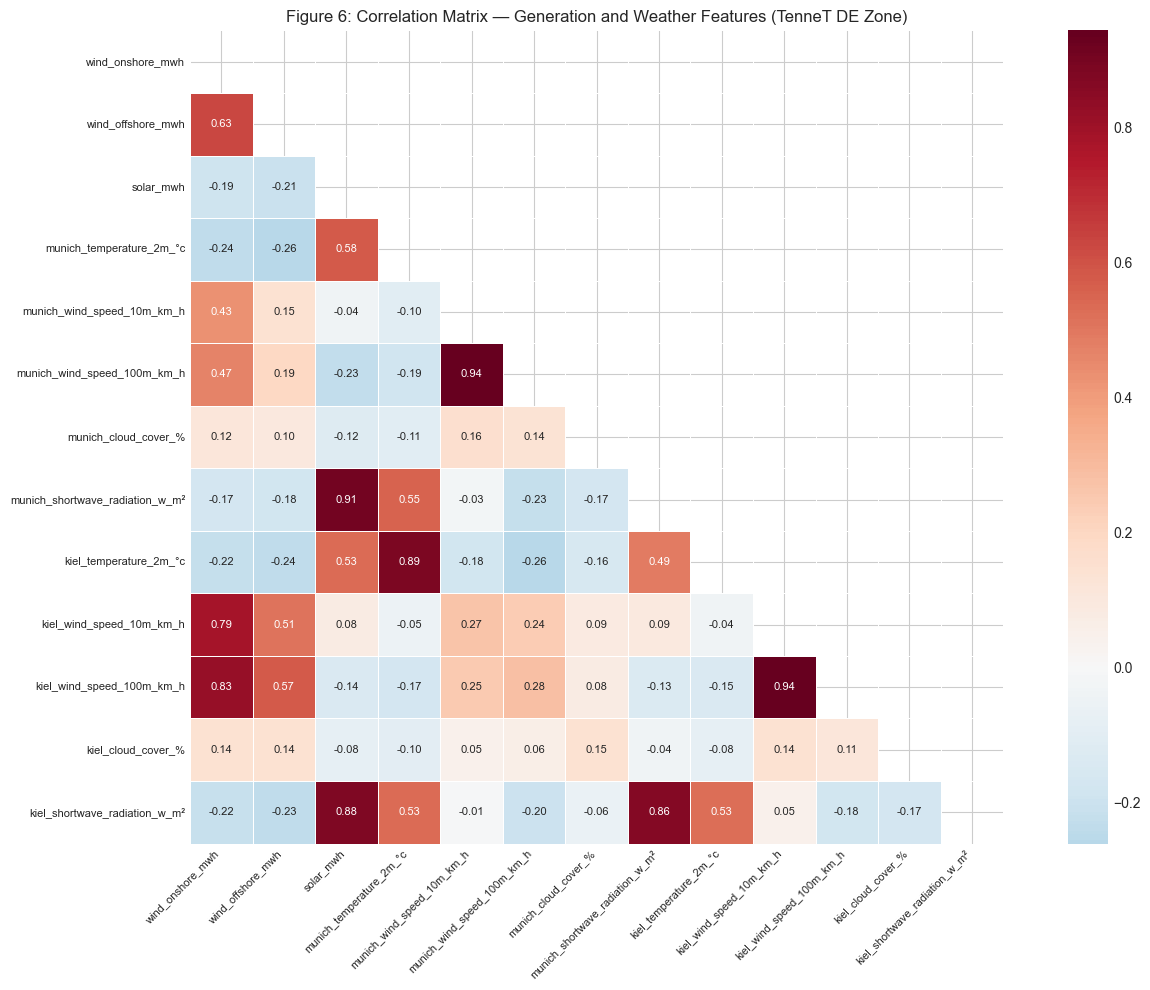

Correlation heatmap saved


In [7]:
# ============================================================
# Correlation heatmap between generation targets and
# weather features from Munich and Kiel
# High correlations confirm weather features are good predictors
# ============================================================
cols_for_corr = target_cols + weather_cols
corr_matrix = df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})

ax.set_title('Figure 6: Correlation Matrix — Generation and Weather Features (TenneT DE Zone)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation heatmap saved')


### Interpretation — Correlation Analysis

Figure 6 reveals the strength and direction of relationships between generation targets and weather features. Kiel wind speed at 100m shows the strongest positive correlation with wind onshore generation (r ≈ 0.83), confirming that Kiel is an appropriate representative weather location for capturing wind conditions in the northern TenneT zone. Munich shortwave radiation shows the strongest positive correlation with solar generation (r ≈ 0.91), validating Munich as the representative location for solar weather features. A notable negative correlation exists between solar and wind generation (r ≈ -0.19), reflecting their opposing seasonal patterns — when wind is strong (winter), solar is weak, and vice versa.

**Sustainability relevance:** The complementary nature of wind and solar generation is highly valuable for grid operators. When forecasting both simultaneously, the model can exploit this negative correlation to better predict total renewable output. This combined forecasting approach supports more efficient grid balancing and reduces the need for fossil fuel backup, directly contributing to lower CO₂ emissions.


## Step 8 — Weather vs Generation Scatter Plots


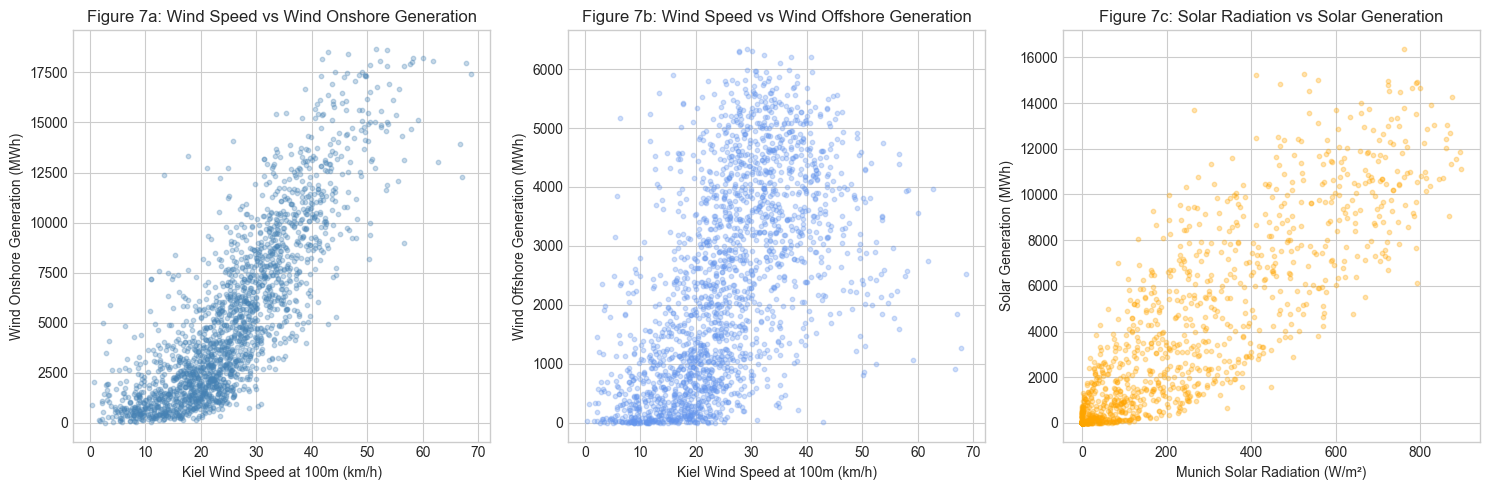

Scatter plots saved


In [8]:
# ============================================================
# Scatter plots showing relationship between key weather
# features and generation output
# Non-linear relationships confirm AI approaches are necessary
# Column names updated to match BEST notebook output
# ============================================================
sample = df.sample(2000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(sample['kiel_wind_speed_100m_km_h'], sample['wind_onshore_mwh'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Kiel Wind Speed at 100m (km/h)')
axes[0].set_ylabel('Wind Onshore Generation (MWh)')
axes[0].set_title('Figure 7a: Wind Speed vs Wind Onshore Generation')

axes[1].scatter(sample['kiel_wind_speed_100m_km_h'], sample['wind_offshore_mwh'],
                alpha=0.3, color='cornflowerblue', s=10)
axes[1].set_xlabel('Kiel Wind Speed at 100m (km/h)')
axes[1].set_ylabel('Wind Offshore Generation (MWh)')
axes[1].set_title('Figure 7b: Wind Speed vs Wind Offshore Generation')

axes[2].scatter(sample['munich_shortwave_radiation_w_m²'], sample['solar_mwh'],
                alpha=0.3, color='orange', s=10)
axes[2].set_xlabel('Munich Solar Radiation (W/m²)')
axes[2].set_ylabel('Solar Generation (MWh)')
axes[2].set_title('Figure 7c: Solar Radiation vs Solar Generation')

plt.tight_layout()
plt.savefig('fig_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plots saved')


### Interpretation — Non-Linear Relationships

Figure 7 shows scatter plots between the most important weather features and generation targets. All three plots reveal clearly non-linear relationships. Wind generation does not increase linearly with wind speed — at low speeds generation is near zero, then increases rapidly before plateauing at high wind speeds (reflecting turbine cut-in and rated power limits). Solar generation shows a fan-shaped distribution against solar radiation — at low radiation, generation is always low, but at high radiation levels there is a wide spread of values, reflecting the influence of other factors such as temperature, cloud cover and panel orientation.

**Justification for AI:** These non-linear relationships are the strongest justification for using machine learning and deep learning over traditional linear regression or ARIMA models. A linear model assumes a straight-line relationship between inputs and outputs — these scatter plots clearly show that assumption is violated. MLP and LSTM neural networks can capture these complex non-linear patterns, making them the appropriate choice for this forecasting task.


## Step 9 — Summer vs Winter Comparison


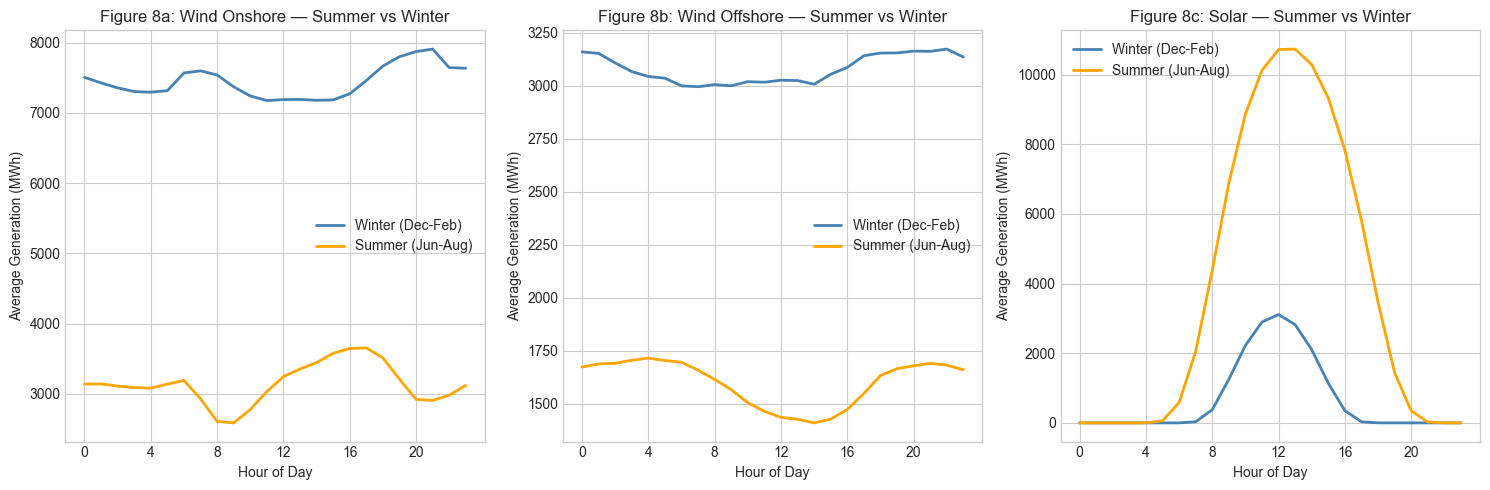

Summer vs Winter plot saved


In [9]:
# ============================================================
# Compare generation patterns between summer and winter
# Highlights strong seasonal variability that
# makes forecasting challenging and justifies using AI
# ============================================================
summer = df[df.index.month.isin([6, 7, 8])]
winter = df[df.index.month.isin([12, 1, 2])]

summer_hourly = summer[target_cols].groupby(summer.index.hour).mean()
winter_hourly = winter[target_cols].groupby(winter.index.hour).mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(winter_hourly.index, winter_hourly['wind_onshore_mwh'],
             color='steelblue', linewidth=2, label='Winter (Dec-Feb)')
axes[0].plot(summer_hourly.index, summer_hourly['wind_onshore_mwh'],
             color='orange', linewidth=2, label='Summer (Jun-Aug)')
axes[0].set_title('Figure 8a: Wind Onshore — Summer vs Winter')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Generation (MWh)')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 4))

axes[1].plot(winter_hourly.index, winter_hourly['wind_offshore_mwh'],
             color='steelblue', linewidth=2, label='Winter (Dec-Feb)')
axes[1].plot(summer_hourly.index, summer_hourly['wind_offshore_mwh'],
             color='orange', linewidth=2, label='Summer (Jun-Aug)')
axes[1].set_title('Figure 8b: Wind Offshore — Summer vs Winter')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Generation (MWh)')
axes[1].legend()
axes[1].set_xticks(range(0, 24, 4))

axes[2].plot(winter_hourly.index, winter_hourly['solar_mwh'],
             color='steelblue', linewidth=2, label='Winter (Dec-Feb)')
axes[2].plot(summer_hourly.index, summer_hourly['solar_mwh'],
             color='orange', linewidth=2, label='Summer (Jun-Aug)')
axes[2].set_title('Figure 8c: Solar — Summer vs Winter')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Average Generation (MWh)')
axes[2].legend()
axes[2].set_xticks(range(0, 24, 4))

plt.tight_layout()
plt.savefig('fig_summer_vs_winter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summer vs Winter plot saved')


### Interpretation — Summer vs Winter Contrast

Figure 8 demonstrates the dramatic seasonal contrast in generation behaviour. Wind onshore generation in winter is approximately 2.5 times higher than in summer across all hours of the day, reflecting the dominance of strong westerly winds in the northern TenneT zone during winter months. Solar generation in summer peaks at over 11,000 MWh around noon, compared to only around 3,000 MWh at the same hour in winter — a difference of more than 3.5 times driven by reduced daylight hours and lower solar angle in December and January.

**Link to AI and sustainability:** These large seasonal differences mean that a model trained only on summer data would perform poorly in winter, and vice versa. The models must learn patterns that generalise across all seasons — a requirement that deep learning models with sufficient training data are well-suited to meet. The month_sin and month_cos features in Notebook 1 are specifically designed to give the models seasonal context. Accurate seasonal forecasting directly supports the integration of renewables into the grid throughout the year, reducing fossil fuel backup activation in both winter and summer.


## Step 10 — EDA Summary


In [10]:
# ============================================================
# Summary of key EDA findings for the report
# ============================================================
print('=' * 60)
print('NOTEBOOK 2 — EDA COMPLETE')
print('=' * 60)
print(f'\nKEY FINDINGS:')
print(f'Wind onshore mean:   {df["wind_onshore_mwh"].mean():.0f} MWh')
print(f'Wind onshore max:    {df["wind_onshore_mwh"].max():.0f} MWh')
print(f'Wind offshore mean:  {df["wind_offshore_mwh"].mean():.0f} MWh')
print(f'Wind offshore max:   {df["wind_offshore_mwh"].max():.0f} MWh')
print(f'Solar mean:          {df["solar_mwh"].mean():.0f} MWh')
print(f'Solar max:           {df["solar_mwh"].max():.0f} MWh')
print(f'Solar zero hours:    {(df["solar_mwh"] == 0).sum():,} (night hours)')
print(f'\nFIGURES SAVED:')
print('fig_annual_generation.png   — annual generation trends')
print('fig_monthly_patterns.png    — monthly seasonal patterns')
print('fig_hourly_profiles.png     — hourly generation profiles')
print('fig_boxplots.png            — generation distributions')
print('fig_correlation_heatmap.png — weather-generation correlations')
print('fig_scatter_plots.png       — non-linear relationships')
print('fig_summer_vs_winter.png    — seasonal contrast')
print('=' * 60)
print('\nKEY CONCLUSIONS:')
print('- High variability in all targets justifies AI forecasting')
print('- Non-linear relationships confirm neural networks are needed')
print('- Opposing seasonal patterns between wind and solar confirmed')
print('- Kiel wind speed and Munich solar radiation are strongest predictors')
print('- Cyclic time features essential for capturing daily/seasonal patterns')
print('=' * 60)
print('Ready for Notebook 3 — Time Series Analysis')


NOTEBOOK 2 — EDA COMPLETE

KEY FINDINGS:
Wind onshore mean:   5139 MWh
Wind onshore max:    20024 MWh
Wind offshore mean:  2322 MWh
Wind offshore max:   6490 MWh
Solar mean:          2349 MWh
Solar max:           17200 MWh
Solar zero hours:    3,693 (night hours)

FIGURES SAVED:
fig_annual_generation.png   — annual generation trends
fig_monthly_patterns.png    — monthly seasonal patterns
fig_hourly_profiles.png     — hourly generation profiles
fig_boxplots.png            — generation distributions
fig_correlation_heatmap.png — weather-generation correlations
fig_scatter_plots.png       — non-linear relationships
fig_summer_vs_winter.png    — seasonal contrast

KEY CONCLUSIONS:
- High variability in all targets justifies AI forecasting
- Non-linear relationships confirm neural networks are needed
- Opposing seasonal patterns between wind and solar confirmed
- Kiel wind speed and Munich solar radiation are strongest predictors
- Cyclic time features essential for capturing daily/seasonal

### Overall EDA Conclusions

The exploratory data analysis confirms five key findings that directly inform the modelling approach:

1. **High variability** across all three generation targets — wind onshore standard deviation is 4,190 MWh against a mean of 5,130 MWh — confirms that simple persistence or average-based forecasting would be highly inaccurate.

2. **Non-linear relationships** between weather features and generation output — confirmed by scatter plots — show that linear regression alone cannot capture the full complexity of the data, justifying the use of MLP and LSTM.

3. **Multi-scale temporal patterns** — daily, weekly and seasonal — require models that can learn across multiple time horizons simultaneously, which is a key strength of LSTM over simpler models.

4. **Strong weather feature correlations** — Kiel wind speed (r=0.83 with wind) and Munich solar radiation (r=0.91 with solar) — validate the dual-location weather data approach and confirm these features will be highly informative for the AI models.

5. **Sustainability context** — the growing trend in renewable generation and the challenges of variability directly link this forecasting problem to SDG 7 (Clean Energy) and SDG 13 (Climate Action). Every improvement in forecast accuracy reduces fossil fuel backup activation and CO₂ emissions.
